<a href="https://colab.research.google.com/github/tagemehta/20.C01/blob/main/pset2_bio_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center> Problem Set 2 (bio)<center>
<center> Spring 2026 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51, 20.C01/20.C51 <center>
<center> Due: Wednesday, April 13, 2026 at 3:00 PM ET. <center>

<b>Name: Tage Mehta</b>

<b>Kerberos id: 983987700</b>

# Background

Modern biological and materials engineering increasingly rely on the automated analysis of complex data, ranging from genomic sequences to high-resolution microscopic imagery. This problem set explores two foundational applications of deep learning:

1.  **Sequence-Based Classification**: You will investigate **DNA binding sites**—specific fragments where proteins or other molecules interact with DNA to regulate critical biological functions like transcription. Using datasets derived from **ChIP sequencing** (Chromatin Immunoprecipitation sequencing), you will build a model to classify these sites based on their nucleotide sequence.
2.  **Computer Vision for Image Segmentation**: Advancements in electron and optical microscopy allow us to probe structures at multiple scales. To process these massive datasets efficiently, machine learning is used to identify physical and chemical patterns. You will work with image data, which is represented computationally as a 3D tensor consisting of color, width, and height dimensions.

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/figures/image_data_struct.png" width="400px" />
</div>
<div align="center">
    Fig 1: DNA sequence data and binding site motifs.
</div>


In materials and biological engineering, advanced imaging techniques using electron and optical microscopy can probe structures at multiple scales to better understand the underlying physical and chemical processes. When this information is processed in large batches, automated image processing programs using machine learning can improve efficiency and accuracy. You will use a U-net model to perform image segmentation on cell images to identify the locations and boundaries of nuclei in cells. For this task, you will be predicting an image filter. This will help scientists process images more efficiently to detect and understand different disease states of cells.


## Main Objectives

* **Build a Sequence Classifier**: Develop a deep learning model to accurately identify DNA binding sites from sequence data to better understand protein-DNA interactions.
* **Implement Image Segmentation**: Utilize a **U-Net** architecture to perform image segmentation on cellular data.
* **Identify Cellular Boundaries**: Automate the detection of nuclei locations and boundaries within cell images.
* **Enhance Diagnostic Efficiency**: Predict image filters that assist scientists in processing biological images more accurately to detect and analyze various disease states.

# Instructions

- This problem set has two modeling tasks with several sub-questions. Points for each section are shown in <span style="color:blue">blue</span>. Total points: 100.

- To get started, make your own copy of this notebook template in Colab (e.g., “Save a copy in Drive”) before editing.

    - Important: this problem set requires a GPU. In Google Colab go to `Edit -> Notebook settings` and set the `Hardware accelerator` to a GPU before running the notebook (changing the runtime resets the notebook). See the GPU section below for additional help.

- Collaboration is encouraged and AI tools are permitted, but submitting work that is not your own is plagiarism. Any collaboration or assistance from others or from an LLM (including utilities integrated in Colab) must be described at the end of your submission.

- Additional notes about how to use this template:
    - Put your code in the code blocks flagged with `############# Code ##########`.

    -  Numerical answers yielded from running the code should be included in an Answer Block (see cells below).

    - We have provided print statements where numerical answers are expected.

    -  Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

    - When a qualitative answer is expected, place those comments as Markdown/Text cells; when asked for within Code blocks, you can write answer as code comments by placing a # before your answer.

- Submission: upload your completed `pset2.ipynb` to Gradescope. Ensure the notebook runs without error and includes all necessary code, plots, and outputs. Comments are encouraged; place conceptual answers in Markdown/Text cells.

### Download required data & install packages

In [1]:
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/dna_binding.csv
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/cell_segmentation_jpeg.tar.gz
!tar -xf cell_segmentation_jpeg.tar.gz

--2026-04-11 02:30:59--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/dna_binding.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1408340 (1.3M) [text/plain]
Saving to: ‘dna_binding.csv’

dna_binding.csv     100%[===================>]   1.34M  --.-KB/s    in 0.06s   

2026-04-11 02:31:00 (23.9 MB/s) - ‘dna_binding.csv’ saved [1408340/1408340]

--2026-04-11 02:31:00--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/cell_segmentation_jpeg.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiti

In [2]:
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from torchvision.io import read_image
import torchvision.transforms as transforms
from torchvision.models import vgg16
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.utils import shuffle
import glob

import os
import PIL
from PIL import Image
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import imageio
from skimage import io, color



matplotlib.rcParams.update({'font.size': 15})
matplotlib.rc('lines', linewidth=3, color='g')
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams["xtick.major.size"] = 6
matplotlib.rcParams["ytick.major.size"] = 6
matplotlib.rcParams["ytick.major.width"] = 2
matplotlib.rcParams["xtick.major.width"] = 2
matplotlib.rcParams['text.usetex'] = False

## <center>Problem 1: Predicting DNA Binding Sites</center>

In this part, you will write a pipeline that builds and trains a model to predict if a section of DNA sequence is a binding site for a protein. You will be provided a dataset of DNA sequences and a binary label 0/1 that indicates if the sequence binds to a protein or not. The sample data format is presented in Table 1.

<div align="center">
    Table 1: Dataframe snapshot from DNA binding data
</div>

| DNA sequence | binder or not |
| :--- | :--- |
| `ATCGGGAA...` | 1 |
| `TGCAGTAT...` | 0 |
| ... | ... |


This part will require you to implement a deep neural network in PyTorch, just as you did in Problem Set 1. If you need to, please go through the PyTorch tutorial [here](https://pytorch.org/tutorials/beginner/basics/intro.html) and the quickstart guide [here](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html).

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/figures/chip.jpeg" width="400px" />
</div>
<div align="center">
    Fig 2: A typical ChIP workflow (<a href="https://www.creativebiomart.net/epigenetics/services/chromatin-analysis-service/chip-based-service/chip-seq-service/histone-chip-seq/">source</a>)
</div>

You'll want a GPU for this part. Request one now.

In [3]:
df = pd.read_csv("./dna_binding.csv")

sequences = df.seq.values
y = df.bind.values

### 1.1 <span style="color:blue">(20 points) </span> Build Datasets and DataLoaders in PyTorch

Now you will construct your data processing pipeline. First load the DNA sequence data with the code provided. Because the data is loaded as strings like "ATGTCA...", you will need to one-hot encode the DNA sequences into bit vectors of size 4 (corresponding to the 4 possible DNA bases A, T, G, and C) and split the data set into 80% train and 20% test. Further retrieve 10% of your training data as the validation set which will be used to check for training convergence. Because training a deep neural network takes time, so we won't perform cross validation or hyperparameter optimization.

**Task 1**: One-hot encode DNA sequence data.

In [4]:
def SeqEnc(sequences):
    '''
    A function to one-hot encode DNA sequences

    Args:
        sequences (list): list of DNA sequences

    Returns:
        np.array: array with shape (N,C,4) where N is the number of sequences
        and C is the sequence length
    '''
    ################ Code #################
    def one_hot_encode(char):
      if char == 'A':
        return np.array([1, 0, 0, 0])
      elif char == 'T':
        return np.array([0,1,0,0])
      elif char == 'G':
        return np.array([0,0,1,0])
      elif char == 'C':
        return np.array([0,0,0,1])

    encoded = []

    for sequence in sequences:
        encoded.append([one_hot_encode(char) for char in list(sequence)])

    return np.array(encoded)


    ################ Code #################

X = SeqEnc(sequences)
print("Shape of X is {}.".format(X.shape))

Shape of X is (12904, 101, 4).


Next, you need to construct your dataset and loader, with `torch.utils.data.Dataset` and `torch.utils.data.DataLoader`. Mimic our code from Problem Set 1 and the Quickstart guide to write a `dataset` class. Essentially, you need to implement the `__getitem__()` method that return a sequence `x` and its corresponding label `y` given an `index`. Construct train, validation and test data loader with `batch_size=256`, using your train, validation and test datasets.

**Task 2**: Implement your dataset class that takes in your data.

In [5]:
# Generate dataset
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(np.array(X))  # store X as a pytorch Tensor
        self.y = torch.Tensor(np.array(y))  # store y as a pytorch Tensor
        self.len=len(self.X)                # number of samples in the data

    def __getitem__(self, index):
    ################ Code #################
        return self.X[index], self.y[index]

    ################ Code #################

    def __len__(self):
        return self.len

**Task 3**: Define your Datasets and DataLoaders.

In [6]:
# Define dataset
X_train = SeqEnc(sequences) # fill in code here
y_train = y # fill in code here

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

#Build Dataset
train_data = SequenceDataset(X_train, y_train) # fill in code here
val_data = SequenceDataset(X_val, y_val) # fill in code here
test_data = SequenceDataset(X_val, y_val) # fill in code here

# Build DataLoader
batch_size = 256
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True) # fill in code here
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=True) # fill in code here
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True) # fill in code here

# Check data shapes
for loader in [train_dataloader, val_dataloader, test_dataloader]:
    for index, batch in enumerate(loader):
        # Your batch returns a X, y stacked in a batch
        X_batch, y_batch = batch[0], batch[1]
        print(X_batch.shape, y_batch.shape)
    print()

torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.

**Task 4**: The concept of batching data might still be new to you, so take a moment to think about what it's doing and why (and optionally, do some brief research on your own about batching in deep learning). What is the benefit of batching your data into mini-batches versus using the entire dataset to optimize the model all at once?

It is often infeasible to load an entire dataset into memory at once so batching solves this problem. It also is computationally expensive to take a gradient over an entire dataset so you can estimate it using a batch. This estimation also provides a way to avoid getting stuck in local minima during optimization.

### 1.2 <span style="color:blue">(20 points) </span> Build an LSTM-based binding classifier

In this section, you will build a DNA sequence classifier with recurrent neural networks. In contrast to a standard feed forward neural network (i.e. a multi-layer perceptron), an RNN is a specialized network architecture that operates on sequential data such as text, DNA sequences, and stock market prices. When RNNs operate on an input at a current time point, it considers not just the value of the current input, but also what it has learned from the inputs it received previously through a hidden context vector. It is through this persistent context vector that the model architectures captures the sequential structure of our data.

Now, let us try to understand the math behind a RNN. First, recall that a single transformation of a neural network requires the following computation:
$$\sigma( W x + b)$$
where $x$ is the data, $W$ is a learned matrix, $\sigma$ is a element-wise nonlinear transformation, and $b$ is a learned bias. If we applied this calculation to our sequential data as one vector, we will have ignored the sequential (e.g., time-varying) nature of our data. RNNs are designed to operate on sequences one element at a time.



Suppose our data has the form $\{x_0, x_1, x_2, .... x_t, .... x_T\}$; an RNN will sequentially construct a hidden embedding $h_t$ for each $x_t$:
$$h_t = \sigma(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$

In this equation $t$ is the index for the element in your sequence. $x_t$ is your sequence data, and the embedding $h_t$ is the representation learned up to time $t$. At step $t$, $W_{ih} x_t + b_{ih}$ transforms the data $x_t$ to a hidden state and $W_{hh} h_{t-1} + b_{hh}$ linearly transforms the hidden embedding of the *previous* state $h_{t-1}$ to produce the next hidden state $h_t$. The two contributions (from $h_{t-1}$ and $x_t$) are added together and passed through a nonlinear activation function, $\sigma$. This procedure is applied to the sequence from $x_0$ all the way to $x_T$ with the same set of parameters $\{W_{ih}, W_{hh}, b_{ih}, b_{hh}\}$ for $T+1$ times.

For this pset, we will use a long short-term memory (LSTM) model, which is a variant of the vanilla RNN described above. LSTMs have been very successful in deep learning applications for natural language processing. In 2017, Facebook switched to using LSTMs to perform billions of language translations on user comments. In contrast to regular RNNs described above, LSTMs contain a gated 'memory cell' to store long-range correlation along the sequence. You are not required to understand the inner-workings of an LSTM for this assignment (although you are encouraged to read about it on your own [here](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)).



Now, let us talk about how to construct a classifier using LSTMs in PyTorch. You will first apply an LSTM on the one-hot encoded sequential data you prepared in the previous part using the `torch.nn.LSTM` class to construct a learned representation. Then, you will extract the parameterized hidden state after the final input, $h_{T}$, as an input to an MLP. The input dimension of the MLP should have the same dimension as the $h_T$ and should output a scalar for each sample. Finally, a sigmoid activation function on the scalar output will provide a probability between 0 and 1 corresponding to the probability that this sequence is a DNA binding site. To summarize, there are three elements you need to construct:

* `lstm`: a LSTM module (`torch.nn.LSTM()`)
* `mlp`: a neural net (`torch.nn.Sequential()`, as in Problem Set 1). Use 2 hidden layers, each with $\tanh$ activation, and a final output layer with 1 output dimension.
* `sigmoid`: an element-wise sigmoid transformation (`torch.nn.Sigmoid()`)

In terms of mathematical equations:

$$
\begin{aligned}
    \{h_t\}, h_T, c_T &= \text{lstm}(\{x_t\}) \\
    \text{prob} &= \text{sigmoid} ( \text{mlp}(h_T) )
\end{aligned}
$$

In this equation, $\{x_t\}$ is the one-hot encoded DNA sequence, $\{h_t\}$ are the hidden embeddings of the sequence, $h_T$ is the embedding of the last element of the sequence. $c_T$ is the cell state of the last element in the sequence. $h_T$ is parameterized to encode the information of the entire sequence, and is the representation you need to use to feed into an MLP regressor.

For `torch.nn.LSTM`, please set `batch_first=True`, `num_layers=1`, `bidirectional=True`, and specify `hidden_size=hidden_dim` (the input to the `LSTMSeq` class). Since we're using a bidirectional LSTM, you'll have two hidden states produced (one for each direction); use the one corresponding to the backwards direction as input for the MLP, which will be $h_T[1]$ or $h_T[-1]$. For the `mlp`, use hidden dimensionality of `hidden_dim` in both layers. We have provided an example computation of LSTM-based classifier in the template file to help guide you, as well as some skeleton code.

The following example will help familiarize you with the LSTM.

In [9]:
# Define a LSTM module
lstm_model = nn.LSTM(input_size=4, hidden_size=16, num_layers=1, batch_first=True, bidirectional=True).to("cpu") # "cpu" is the device id

# Send your batch to a GPU
X_batch, y_batch = next(iter(train_dataloader))
X_batch = X_batch.to("cpu")
y_batch = y_batch.to("cpu")

# Propagate your batch into your model
lstm_out, (ht, ct) = lstm_model(X_batch)
print(lstm_out.shape, ht.shape, ct.shape)

# You can play with hyperparameters to see how your output change

torch.Size([256, 101, 32]) torch.Size([2, 256, 16]) torch.Size([2, 256, 16])


**Task**: Build your LSTM-based classifier as a nn.Module.

In [10]:
class LSTMseq(torch.nn.Module) :
    def __init__(self, input_dim, hidden_dim) :
        super().__init__()
        ################ Code #################

        # Define a LSTM module
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True, bidirectional=True)
        # Define a MLP regressor
        self.mlp = nn.Sequential(torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.Tanh(), torch.nn.Linear(hidden_dim, hidden_dim),
                                  torch.nn.Tanh(), torch.nn.Linear(hidden_dim, 1))
        # Define a sigmoid transform
        self.sigmoid = nn.Sigmoid()
        ################ Code #################

    def forward(self, x):
        ################ Code #################

        # Apply LSTM
        lstm_out, (ht, ct) = self.lstm(x)
        backwards_lstm_ht = ht[1]
        # Pass output into a MLP
        mlp_out = self.mlp(backwards_lstm_ht)
        # Transform output into probabilites
        proba = self.sigmoid(mlp_out)
        # Return probabilities

        ################ Code #################
        return proba

In [11]:
# Test your ouput on a batch
clf = LSTMseq(input_dim=4, hidden_dim=16).to('cpu')
print(clf(X_batch).shape)

torch.Size([256, 1])


### 1.3 <span style="color:blue">(20 points) </span> Implement functions for training and testing

As in Problem Set 1, set up the Adam optimizer to train your model, with a learning rate `lr` of `1e-2`. In this problem, we will also be using a learning rate scheduler, specifically the scheduler `torch.optim.lr_scheduler.ReduceLROnPlateau`. This is a common strategy to prevent overfitting or overshooting a loss minimum by gradually reducing the learning rate during training. We have provided the scheduler for you in the skeleton code.

Next, write your training loop, following the Quickstart guide or the example we provided in Problem Set 1. Unlike before, this is a classification problem, so you will want to compute the binary cross entropy loss (`nn.functional.binary_cross_entropy()`) which requires you to input classification probabilities and the ground truth labels from your data. This should be implemented in the provided `train()` function, which already loops over minibatches for you. Record the loss of each batch and compute the average loss for all batches. Your `train()` function should return the average training loss.

Similarly, complete the `validate()` function to iterate over validation data and return the mean validation loss; remember to ensure that the validation function does not call the optimizer because the validation dataset is not used for training. You can make sure this is the case by calling `model.eval()` and turn on the `torch.no_grad()` context manager at the beginning of your validation function (we have implemented that for you). You will need to call `model.train()` to turn the gradients and optimizer updates back on in the `train()` function.

Finally, complete the `evaluate()` function. This function takes in data and produces the model's predictions, along with the true values for that dataset. You'll use it to evaluate your model's predictions on the test data and measure model performance.

**Task 1**: Implement the training and validation loops, and evaluation function.

In [12]:
def train(model, dataloader, optimizer, device):

    '''
    A function to train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer): Optimizer object to interface gradient calculation and optimization
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    batch_loss = []
    model.train() # Set model to training mode

    for batch in dataloader:
        seq, label = batch
        seq = seq.to(device)
        label = label.to(device)

        # train your model on each batch here
        ################ Code #################
        label_pred = model(seq)
        loss = nn.functional.binary_cross_entropy(label_pred, label.unsqueeze(1))

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        batch_loss.append(loss.item())

        ################ Code #################

    return np.mean(batch_loss)

def validate(model, dataloader, device):

    '''
    A function to validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the validation data
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    val_loss = []
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        for batch in dataloader:
            seq, label = batch
            seq = seq.to(device)
            label = label.to(device)

            # validate your model on each batch here
            ################ Code #################
            label_pred = model(seq)

            loss = nn.functional.binary_cross_entropy(label_pred, label.unsqueeze(1))
            val_loss.append(loss.item())

            ################ Code #################

    return np.mean(val_loss)

def evaluate(model, dataloader, device):

    '''
    A function to return the classification probabilities and true labels (for evaluation).

    Args:
        model (torch.nn.Module): your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        device (str): Your device

    Returns:
        (np.array, np.array): true labels, predicted probabilities
    '''

    pred_prob = []
    labels = []
    with torch.no_grad():
        model.eval()
        for batch in dataloader:
            seq, label = batch

            seq = seq.to(device)
            label = label.to(device)

            # evaluate your model here
            ################ Code #################
            label_pred = model(seq)
            labels.append(label.cpu())
            pred_prob.append(label_pred.cpu())

            ################ Code #################

    return torch.cat(labels).numpy(), torch.cat(pred_prob).squeeze().numpy()

Looping over the entire training data set once is called an *epoch*. The `train()` and `test()` function you will implement is only for one epoch, and should return a train loss and validation loss computed as averages over all the batches. Train and validate your model for 500 epochs; we have provided you with the code for this. This will take a few minutes.

In [13]:
device = 'cuda:0'
model = LSTMseq(4, 16).to(device)

optimizer = torch.optim.Adam(list(model.parameters()), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5)

val_loss_curve = []
train_loss_curve = []

# Use tqdm for progress bar
tqdm_progress =  tqdm(range(500), desc="Progress")

for epoch in tqdm_progress:
    # Compute train your model on training data
    epoch_loss = train(model, train_dataloader, optimizer, device=device)

    # Validate your on validation data
    val_loss = validate(model, val_dataloader, device=device)

    # Record train and loss performance
    train_loss_curve.append(epoch_loss)
    val_loss_curve.append(val_loss)

    # The learning rate scheduler record the validation loss
    scheduler.step(val_loss)
    tqdm_progress.set_postfix(train_loss=f'{epoch_loss:.3f}', val_loss=f'{val_loss:.3f}', refresh=True)

Progress: 100%|██████████| 500/500 [01:32<00:00,  5.43it/s, train_loss=0.121, val_loss=0.366]


**Task 2**: Record the average train and validation loss for each epoch and plot these on a single graph, using our provided code.

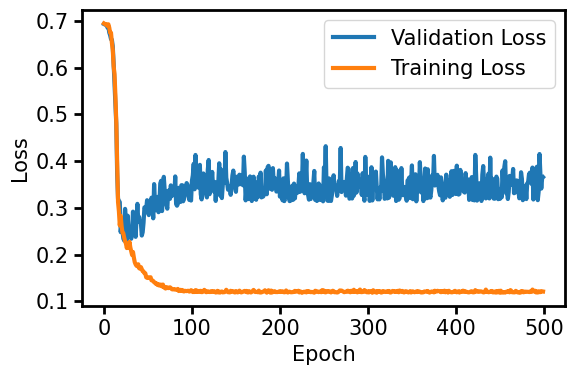

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(val_loss_curve, label='Validation Loss')
ax.plot(train_loss_curve, label='Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right')
fig.tight_layout()

**Task 3**: Finally report your test AUC score of your trained model on the test data. You would need to transform your prediction from `torch.Tensor` to `np.array` to compute ROC/AUC scores. As usual, you should use `sklearn.metrics.roc_auc_score`.

In [15]:
################ Code #################
test_labels, test_preds = evaluate(model, test_dataloader, device)
test_score = roc_auc_score(test_labels, test_preds)

################ Code #################

print("AUC on the test dataset is {}.".format(test_score) )

AUC on the test dataset is 0.9509372600049196.


## Problem 2: Image Segmentation

In computer vision, image segmentation is a computational technique that partitions images into different parts for easier analysis and processing. This technique has been very useful for photo editing and videoconferencing software. For example, Zoom uses image segmentation to add virtual backgrounds to your video stream.

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/figures/cell_seg.png" width="400px" />
  <p><em>
</div>

<div align="center"> Fig 3: Applying image segmentation to cell images. The red lines marks the boundaries of cells.</em></p> </div>

Image segmentation is also useful for analyzing cell images. Accurate and efficient segmentation of the cell nuclei improves the quality of disease states assessment for cells. In this question, you are given a dataset of cell images, each labeled with a pixel-wise mask to indicate if it belongs to a nucleus or not. The dataset comes from [the 2018 Kaggle data science bowl](https://www.kaggle.com/c/data-science-bowl-2018).

### 2.1 <span style="color:blue">(20 points) </span> Build Datasets and DataLoaders

Download the image datasets with code we provided. Make your own image dataset with a `__getitem__()` method that loads and processes images (`X`) and segmentation masks (`y`). Similar to what you did in Part 1, make an `ImageDataset` object as a subclass of `torch.utils.data.dataset`. We provided a function `load_img()` that reads the image and its mask given a path to the image file. The cell images you will load are gray scale. `load_img()` returns a tuple of images as `np.array`s with dimensions of 256 $\times$ 256 (cell image) and 256 $\times$ 256 (mask image). Like in part 1, you can convert them to 256 $\times$ 256 `torch.Tensor`s using `transforms.ToTensor()`.

Build your Datasets (70% train, 10% validation, and 20% test) and DataLoaders with a batch size of 4. To split your data, apply the split to the `paths` list generated in our code, and feed in the resulting `paths` to your `ImageDataset` class.

Parse data from image filepaths.

In [16]:
paths = [path for path in glob.glob("cell_segmentation/*") if "cells" in path]

def load_img(path):
    x = np.array(Image.open(path)) / 255
    y = np.array(Image.open(path.replace("cells","masks"))) / 255
    return x, y

Load one image.


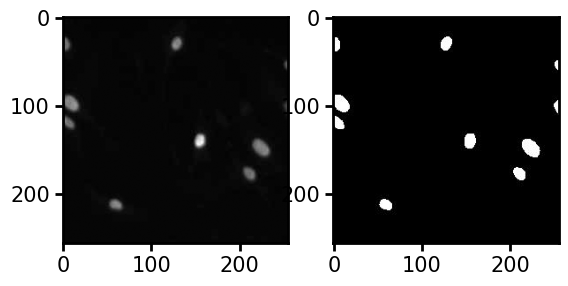

In [17]:
idx = 20
cells, masks = load_img(paths[idx])
fig, axes = plt.subplots(1,2)
axes[0].imshow(cells, cmap='gray')
axes[1].imshow(masks, cmap='gray')

**Task 1**: Implement your ImageDataset class.

In [18]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, transform=None):

        '''
        Image dataset object that loads and transforms images.

        '''

        self.paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        ################ Code #################
        x, y = load_img(self.paths[idx])
        
        # Convert to float32 to match model dtype
        x = x.astype(np.float32)
        y = y.astype(np.float32)
        
        # Apply transforms if provided
        if self.transform:
            x = self.transform(x)
            y = self.transform(y)
        
        # Remove extra channel dimension if present (grayscale images)
        if x.dim() == 3 and x.shape[0] == 1:
            x = x.squeeze(0)
        if y.dim() == 3 and y.shape[0] == 1:
            y = y.squeeze(0)

        ################ Code #################

        return x, y

**Task 2**: Split your data and load your DataLoaders.


In [19]:
################ Code #################

train_paths, test_paths = train_test_split(paths, test_size=0.2, random_state=42)
train_paths, val_paths = train_test_split(train_paths, test_size=0.125, random_state=42)

# Data augmentation for training set: random rotation + convert to tensor
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=360)  # Random rotation from 0 to 360 degrees
])

# No augmentation for validation and test sets: just convert to tensor
val_test_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = ImageDataset(train_paths, transform=train_transform)
val_dataset = ImageDataset(val_paths, transform=val_test_transform)
test_dataset = ImageDataset(test_paths, transform=val_test_transform)

train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)

################ Code #################

Ideally, your model predictions should respect rotational and translational invariance. While CNNs are invariant to translations, rotational symmetry is not embedded in a CNN architecture ([Weiler et al. (2018)](https://arxiv.org/abs/1807.02547)). To implicitly make your model adapt to different possible rotations, you should apply random rotation transformations to your training image samples. This technique is called **data augmentation**.

Do you think random rotation data augmentation was necessary for our specific task of cell image segmentation? Also, why are CNNs invariant to translations? Briefly justify your answer.

For our specific case it makes sense to add random rotation because real microscopy data could have cells in different orientations due to the way the cells were plated, grown, or the configuration of the microscope. CNNs are translation invariant because the same filter gets applied across the whole image and pooling summarizes local features minimizing the effect of local variations.

### 2.2 <span style="color:blue">(20 points) </span> Train a U-Net Model that Performs Image Segmentation

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/figures/unet.png" width="600px" />
</div>
<div align="center">
  Fig 4: The U-Net architecture. The name stems from its U-shaped architecture (<a href="https://arxiv.org/abs/1505.04597">Ronneberger et al. (2015)</a>).
</div>


The model you will use is called U-Net which is a popular method for image segmentation (<a href="https://arxiv.org/abs/1505.04597">Ronneberger et al. (2015)</a>). Unlike a CNN model that successively contracts image information into a scalar output for classification, a U-Net model uses an encoder and a decoder to parameterize pixel-wise output to predict pixel-wise labels (Fig. 1). A final pixel-wise sigmoid transformation is used to ensure that the pixel-wise outputs are from 0 to 1. Mathematically, the model takes an image and outputs an segmentation filter ($f: \mathbb{R}^{256 \times 256} \rightarrow \mathbb{R}^{256 \times 256}$).

A common loss function for training an image segmentation model is the Dice loss (from Sørensen–Dice coefficient) ([Jadon (2020)](https://ieeexplore.ieee.org/document/9274440)). Let $p_i$ be your predicted mask and $t_i$ be your target mask, the Dice loss is defined as:

$$\mathcal{L}_{\text{Dice}} = 1 - \frac{ 2 \sum_i p_i t_i + 1}{ \sum_i p_i +  \sum_i t_i + 1}$$

**Task 1**: Please implement the loss function `dice_loss()` which takes the predicted mask and the labeled mask as arguments. $+1$ is included in the numerator and the denominator to deal with edge cases when there are no predicted mask in an image.

In [36]:
def dice_loss(pred, target):
    """Calculate Dice loss.

    Parameters
    ----------
        pred:
            predictions from the model
        target:
            ground truth label
    """
    loss = None
    ################ Code #################
    
    pixel_target_mult = torch.sum(pred*target)
    pixel_pred_sum = torch.sum(pred)
    target_sum = torch.sum(target)

    loss = 1 - ((2 * pixel_target_mult) + 1)/ (pixel_pred_sum + target_sum + 1)

    ################ Code #################
    return loss

The U-Net Model.

In [21]:
class DownSampling(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, name=None):
        super(DownSampling, self).__init__()

        self.conv = ConvBlock(in_channels, out_channels, kernel_size)
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):

        conv_out = self.conv(x)
        output = self.max_pool(conv_out)

        return output, conv_out


class UpSampling(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, name=None):
        super(UpSampling, self).__init__()

        self.conv = ConvBlock(in_channels, out_channels, kernel_size)
        self.conv_t = nn.ConvTranspose2d(out_channels, out_channels, kernel_size, \
                                         padding=1, stride=2, output_padding=1)


    def forward(self, x, skip):

        conv_out = self.conv(x)
        output = self.conv_t(conv_out)

        output += skip

        return output


class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, padding=1, stride=1, name=None):
        super(ConvBlock, self).__init__()

        block = []
        # first conv layer
        block.append(nn.Conv2d(in_channels, out_channels, kernel_size, \
                               padding=padding, stride=stride))
        block.append(nn.ReLU())
        block.append(nn.BatchNorm2d(out_channels))

        # second conv layer
        block.append(nn.Conv2d(out_channels, out_channels, kernel_size, \
                               padding=padding, stride=stride))
        block.append(nn.ReLU())
        block.append(nn.BatchNorm2d(out_channels))

        # make sequential
        self.conv_block = nn.Sequential(*block)


    def forward(self, x):

        output = self.conv_block(x)

        return output


class UNet(nn.Module):

    def __init__(self, num_kernel=8, kernel_size=3, dim=1, target_dim=1):
        """UNet

        Arguments:
            num_kernel: int
                number of kernels to use for the first layer
            kernel_size: int
                size of the kernel for the first layer
            dims: int
                number of color channels for input images
            target_dim: int
                number of channels for the output mask
        """

        super(UNet, self).__init__()

        self.num_kernel = num_kernel
        self.kernel_size = kernel_size
        self.dim = dim
        self.target_dim = 1

        # encode
        self.encode_1 = DownSampling(self.dim, num_kernel, kernel_size)
        self.encode_2 = DownSampling(num_kernel, num_kernel*2, kernel_size)
        self.encode_3 = DownSampling(num_kernel*2, num_kernel*4, kernel_size)
        self.encode_4 = DownSampling(num_kernel*4, num_kernel*8, kernel_size)

        # bridge
        self.bridge = nn.Conv2d(num_kernel*8, num_kernel*16, kernel_size, padding=1, stride=1)

        # decode
        self.decode_4 = UpSampling(num_kernel*16, num_kernel*8, kernel_size)
        self.decode_3 = UpSampling(num_kernel*8, num_kernel*4, kernel_size)
        self.decode_2 = UpSampling(num_kernel*4, num_kernel*2, kernel_size)
        self.decode_1 = UpSampling(num_kernel*2, num_kernel, kernel_size)

        self.segment = nn.Conv2d(num_kernel, self.target_dim, 1, padding=0, stride=1)
        self.activate = nn.Sigmoid()


    def forward(self, x):

        has_channel = x.ndim == 4
        if not has_channel:
            x = x.unsqueeze(1)

        x, skip_1 = self.encode_1(x)
        x, skip_2 = self.encode_2(x)
        x, skip_3 = self.encode_3(x)
        x, skip_4 = self.encode_4(x)

        x = self.bridge(x)

        x = self.decode_4(x, skip_4)
        x = self.decode_3(x, skip_3)
        x = self.decode_2(x, skip_2)
        x = self.decode_1(x, skip_1)

        x = self.segment(x)

        pred = self.activate(x)

        if not has_channel:
            pred = pred.squeeze(1)

        return pred


    def args_dict(self):
        """model arguments to be saved
        """

        model_args = {'dim': self.dim,
                      'target_dim': self.target_dim,
                      'num_kernel' : self.num_kernel,
                      'kernel_size' : self.kernel_size}

        return model_args

Example model usage.

In [22]:
model = UNet()
y = model(torch.randn(4, 256, 256))

print(y.shape)

torch.Size([4, 256, 256])


A function to plot a segmentation map.


In [23]:
def plot_seg(img, pred_seg, true_seg, mask_cutoff=0.5):

    """ Visualize segmentation results.
    Inputs:
        image: orginal image, shape: 256 x 256
        pred_seg: predicted mask, shape: 256 x 256
        true_seg: true mask, shape: 256 x 256
        mask_cutoff: if the mask values is larger than mask_cutoff, the mask will appear on the image
    """
    img = img.squeeze()
    pred_seg = pred_seg.squeeze()
    true_seg = true_seg.squeeze()

    fig, ax = plt.subplots(1, 3, sharex='col', sharey='row')
    fig.set_size_inches((15,15))

    ax[0].set_title("Original Image")
    ax[1].set_title("Prediction")
    ax[2].set_title("Ground Truth")

    img = np.stack([img,img,img],axis = -1)
    ax[0].imshow(img)
    ax[1].imshow(np.clip(color.label2rgb(pred_seg > mask_cutoff,img,colors=[(255,0,0)],alpha=0.0025, bg_label=0, bg_color=None),0,1))
    ax[2].imshow(np.clip(color.label2rgb(true_seg > mask_cutoff,img,colors=[(255,0,0)],alpha=0.0025, bg_label=0, bg_color=None),0,1))

    plt.show()

We have implemented a untrained U-Net model for you to use. Train your model for 20 epochs with a learning rate of `1e-3` to obtain a model that predicts the segmentation mask for each image. You will need to convert your images and masks to float tensors using `.to(float)` for them to train properly. We have provided an function `plot_seg()` for you to visually compare the predicted segmentation and ground truth segmentation; check the dimensions requirements of `plot_seg()` carefully. When your training is finished, show the segmentation results for three images in the test data using `plot_seg()`.

**Task 2**: Train model

In [46]:
################ Code #################
def train(model, dataloader, optimizer, loss_fn, device):

    '''
    A function to train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer): Optimizer object to interface gradient calculation and optimization
        loss_fn: Loss function to compute the training loss
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    batch_loss = []
    model.train() # Set model to training mode

    for batch in dataloader:
        image, mask = batch
        image = image.to(device)
        mask = mask.to(device)

        # train your model on each batch here
        ################ Code #################
        mask_pred = model(image)
        loss = loss_fn(mask_pred, mask)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        batch_loss.append(loss.item())

        ################ Code #################

    return np.mean(batch_loss)

def validate(model, dataloader, loss_fn, device):

    '''
    A function to validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the validation data
        loss_fn: Loss function to compute the validation loss
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    val_loss = []
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        for batch in dataloader:
            image, mask = batch
            image = image.to(device)
            mask = mask.to(device)
            # validate your model on each batch here
            ################ Code #################
            mask_pred = model(image)

            loss = loss_fn(mask_pred, mask)
            val_loss.append(loss.item())

            ################ Code #################

    return np.mean(val_loss)

device = "cuda:0"
model = UNet().to(device)
optimizer = torch.optim.Adam(list(model.parameters()), lr=1e-3)

train_loss_curve = []
val_loss_curve = []

tqdm_progress =  tqdm(range(20), desc="Progress")
for epoch in tqdm_progress:
    # Compute train your model on training data
    epoch_loss = train(model, train_dataloader, optimizer, dice_loss, device=device)

    # Validate your on validation data
    val_loss = validate(model, val_dataloader, dice_loss, device=device)

    # Record train and loss performance
    train_loss_curve.append(epoch_loss)
    val_loss_curve.append(val_loss)

    # The learning rate scheduler record the validation loss
    scheduler.step(val_loss)
    tqdm_progress.set_postfix(train_loss=f'{epoch_loss:.3f}', val_loss=f'{val_loss:.3f}', refresh=True)
################ Code #################

Progress: 100%|██████████| 20/20 [00:38<00:00,  1.91s/it, train_loss=0.789, val_loss=0.835]


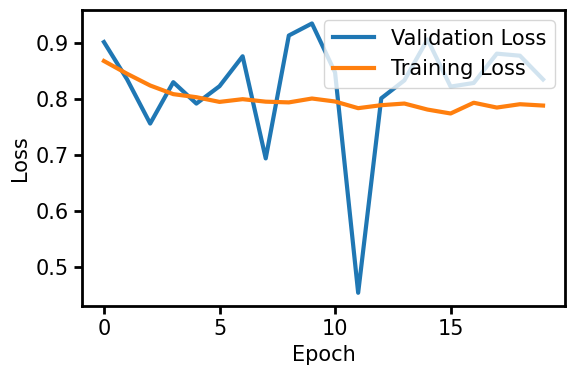

In [47]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(val_loss_curve, label='Validation Loss')
ax.plot(train_loss_curve, label='Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right')
fig.tight_layout()

**Task 3**: Show segmentation results for 3 images from the test dataset.
> **Hint**: Use `.cpu()`, `.detach()`, `.numpy()` on `torch.Tensor`'s


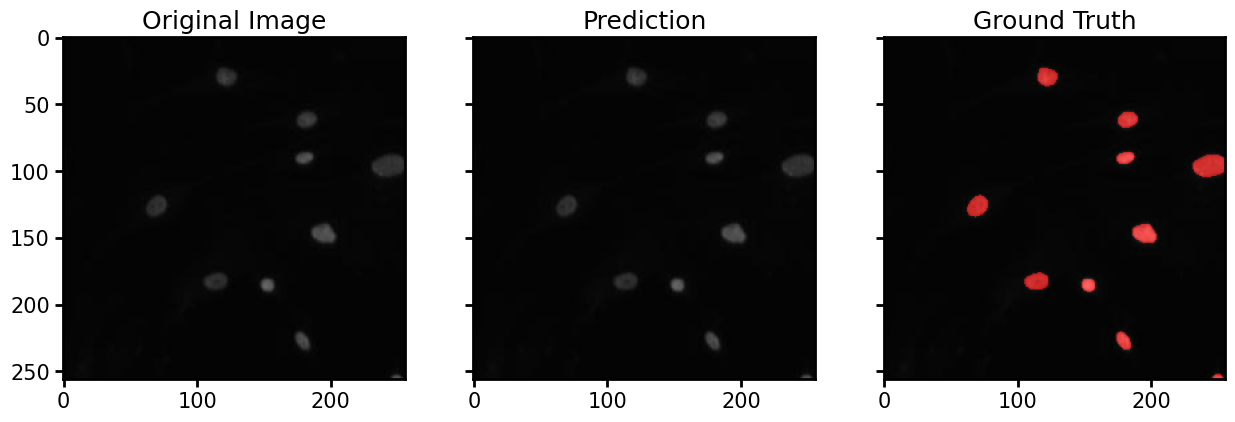

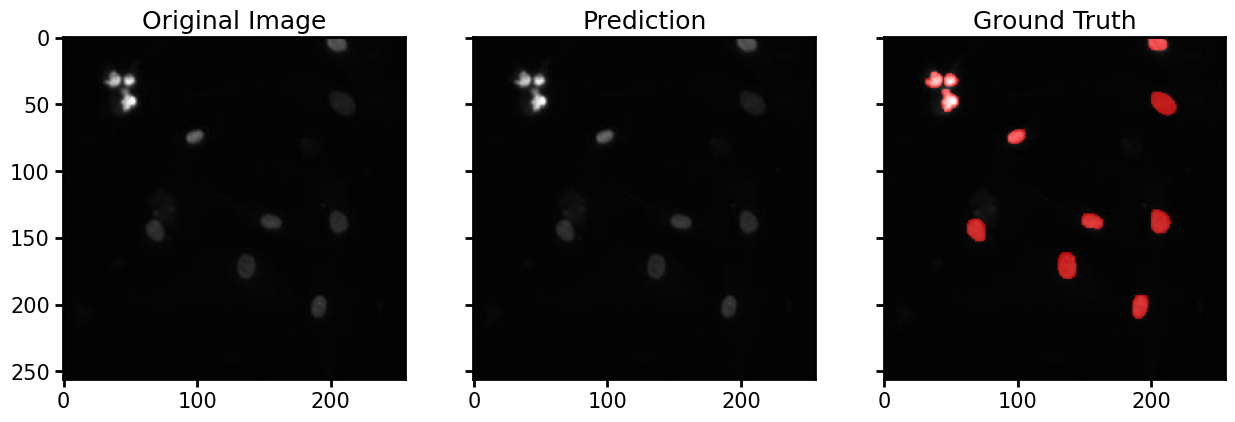

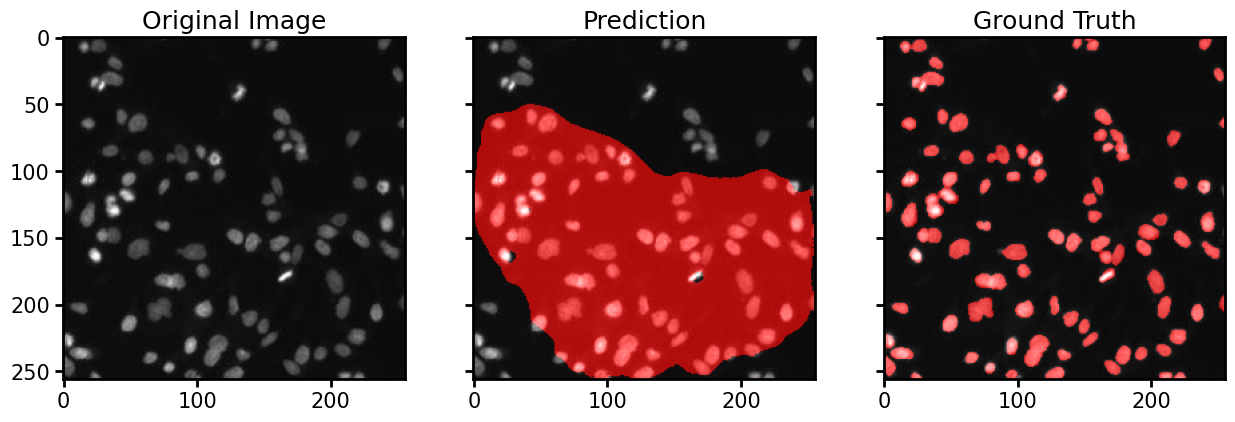

In [53]:
################ Code #################
# set model in eval mode
model.eval()
with torch.no_grad():
  for idx in [20, 30, 40]:
    cells, mask = test_dataset[idx]
    cells = cells.to(device)
    mask_pred = model(cells.unsqueeze(0))
    cells = cells.squeeze(0).cpu().detach().numpy()
    mask_pred = mask_pred.squeeze(0).cpu().detach().numpy()
    plot_seg(cells, mask_pred, mask.cpu().detach().numpy())

################ Code #################

---

# Submission

Congratulations! You've reached the end of the pset. Please submit your completed work as a `.ipynb` to Gradescope. Furthermore, if you had any AI-based assistance or worked with collaborators, please list them in the following cell.

**For submission:**
If your file is less than 10mb, feel free to turn in the `.ipynb` directly.

However, if it is >10mb, please take a look at the `# --- Configuration ---` section of the next cell. You will need to change the `NOTEBOOK_NAME` to match the name of your google colab notebook. After making the applicable changes, make sure to save your file, and then please run the cell which will reduce the size of your generated images and aim for a file size of less than 10 mb. Note that it will also delete cells tagged as "background". Check the output to ensure it didn't delete any of your outputs.

When successful, you'll be prompted to download the reformatted notebook which you can then upload to gradescope.

In [59]:
import io
import os
import base64
import nbformat
import sys
from PIL import Image

# --- Configuration ---
NOTEBOOK_NAME = "pset2_bio_template.ipynb"  # The name of your file
OUTPUT_FILENAME = "pset_2_bio_submission.ipynb"
TAG_TO_REMOVE = "background"
MAX_IMG_WIDTH = 800
# ---------------------

def resize_base64_image(b64_str, mime_type):
    """Resize base64-encoded images to reduce file size."""
    try:
        img_data = base64.b64decode(b64_str)
        img = Image.open(io.BytesIO(img_data))
        if img.width > MAX_IMG_WIDTH:
            ratio = MAX_IMG_WIDTH / img.width
            new_height = int(img.height * ratio)
            img = img.resize((MAX_IMG_WIDTH, new_height), Image.Resampling.LANCZOS)
            buf = io.BytesIO()
            fmt = 'PNG' if 'png' in mime_type else 'JPEG'
            img.save(buf, format=fmt, optimize=True)
            return base64.b64encode(buf.getvalue()).decode('utf-8')
        return b64_str
    except Exception as e:
        return b64_str

def generate_submission():
    """Generate a submission notebook with compressed images."""
    
    # Use absolute path - update this to match your actual file location
    input_path = "/Users/smehta/Desktop/Dev/MIT/20C01/pset2_bio_template.ipynb"
    output_path = "/Users/smehta/Desktop/Dev/MIT/20C01/pset_2_bio_submission.ipynb"
    
    print(f"Reading notebook from: {input_path}")
    
    # Check if file exists
    if not os.path.exists(input_path):
        print(f"ERROR: File not found at {input_path}")
        print(f"Current working directory: {os.getcwd()}")
        return
    
    try:
        with open(input_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)
    except Exception as e:
        print(f"Error reading file: {e}")
        return
    
    new_cells = []
    
    # Filter Cells & Process Images
    for cell in nb.cells:
        tags = cell.get('metadata', {}).get('tags', [])
        tags = [t.lower() for t in tags] if tags else []
        if TAG_TO_REMOVE in tags:
            continue
        
        if 'outputs' in cell:
            for output in cell['outputs']:
                data = output.get('data', {})
                for mime_type in ['image/png', 'image/jpeg']:
                    if mime_type in data:
                        data[mime_type] = resize_base64_image(data[mime_type], mime_type)
        new_cells.append(cell)
    
    nb.cells = new_cells
    
    with open(output_path, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)
    
    file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"\n✓ Success! {OUTPUT_FILENAME} created.")
    print(f"  File size: {file_size_mb:.2f} MB")
    print(f"  Location: {output_path}")
    print(f"\nYou can now submit this file to Gradescope!")

generate_submission()

Reading notebook from: /Users/smehta/Desktop/Dev/MIT/20C01/pset2_bio_template.ipynb
ERROR: File not found at /Users/smehta/Desktop/Dev/MIT/20C01/pset2_bio_template.ipynb
Current working directory: /content


In [58]:
%ls

cell_segmentation/             dna_binding.csv  sample_data/
cell_segmentation_jpeg.tar.gz  drive/
